In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

Create the database

In [ ]:
np.random.seed(42)

#Number of student
n=100

#features
cgpa = np.round(np.random.uniform(5.5,9.8,n),2)
study_hours = np.random.randint(1,10,n)
internships = np.random.randint(0,4,n)
project = np.random.randint(1,6,n)

#Salary/package in LPA
salary = (
    1.5
    + 0.65 * cgpa
    + 0.18 * study_hours
    + 0.75 * internships
    + 0.25 * project
    + np.random.normal(0,0.5,n)
)

salary = np.round(salary,2)

#Create Dataframe
df = pd.DataFrame({
    "CGPA":cgpa,
    "Study Hours":study_hours,
    "Internships":internships,
    "Project":project,
    "Salary":salary,
})

print(df.head())
print(df.shape)

   CGPA  Study Hours  Internships  Project  Salary
0  7.11            7            3        1    9.25
1  9.59            1            0        1    8.62
2  8.65            4            1        4   10.65
3  8.07            4            0        4    8.98
4  6.17            5            3        5    9.15
(100, 5)


Understand the data

In [ ]:
print(df.head())

print("\nDataset shape: ")
print(df.shape)

print("\nData Types: ")
print(df.dtypes)

print("\nDataset description: ")
print(df.describe())

print("\nMissing Values: ")
print(df.isnull().sum())

   CGPA  Study Hours  Internships  Project  Salary
0  7.11            7            3        1    9.25
1  9.59            1            0        1    8.62
2  8.65            4            1        4   10.65
3  8.07            4            0        4    8.98
4  6.17            5            3        5    9.15

Dataset shape: 
(100, 5)

Data Types: 
CGPA           float64
Study Hours      int64
Internships      int64
Project          int64
Salary         float64
dtype: object

Dataset description: 
             CGPA  Study Hours  Internships     Project      Salary
count  100.000000   100.000000   100.000000  100.000000  100.000000
mean     7.521400     4.900000     1.660000    2.910000    9.246000
std      1.279464     2.687419     1.191044    1.443166    1.295339
min      5.520000     1.000000     0.000000    1.000000    6.330000
25%      6.327500     3.000000     1.000000    2.000000    8.477500
50%      7.495000     5.000000     2.000000    3.000000    9.120000
75%      8.642500     7.00

Data distribution

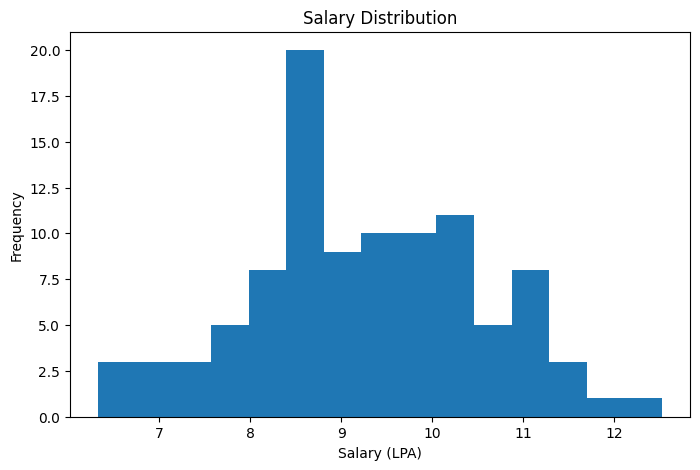

In [ ]:
plt.figure(figsize=(8,5))

plt.hist(df["Salary"], bins = 15)

plt.xlabel("Salary (LPA)")
plt.ylabel("Frequency")
plt.title("Salary Distribution")

plt.show()

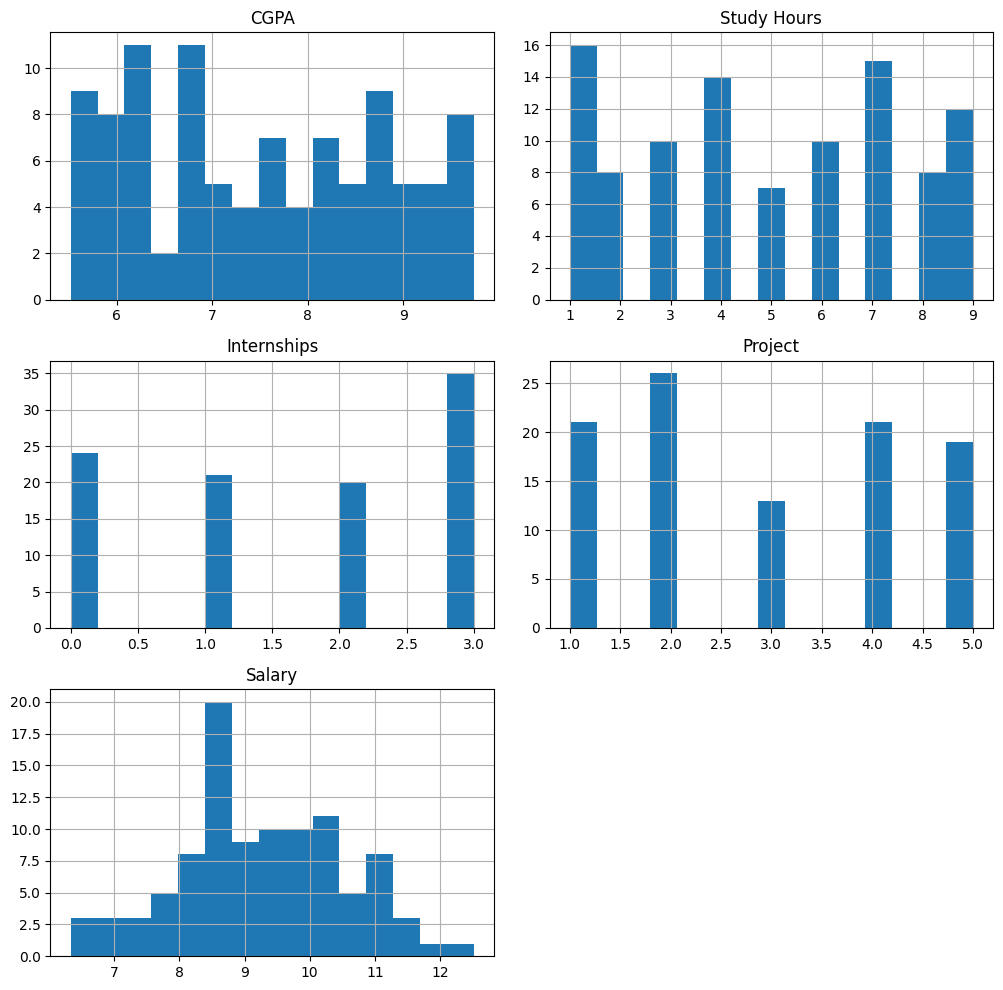

In [ ]:
df.hist(
    figsize=(10,10),
    bins=15
)

plt.tight_layout()
plt.show()

Scatter plots

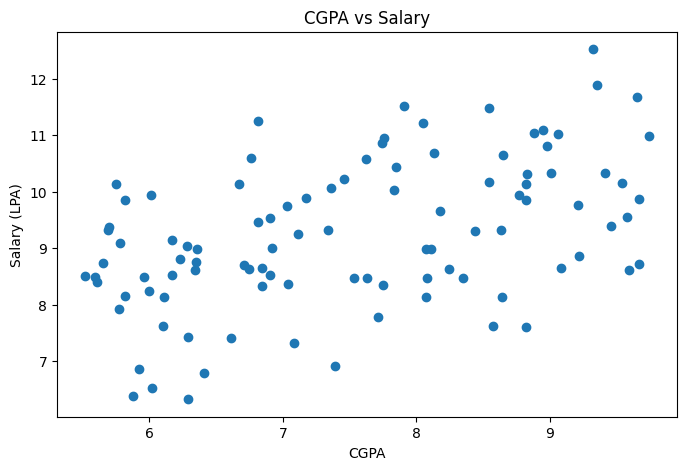

In [ ]:
plt.figure(figsize=(8,5))

plt.scatter(df["CGPA"], df["Salary"])

plt.xlabel("CGPA")
plt.ylabel("Salary (LPA)")
plt.title("CGPA vs Salary")

plt.show()


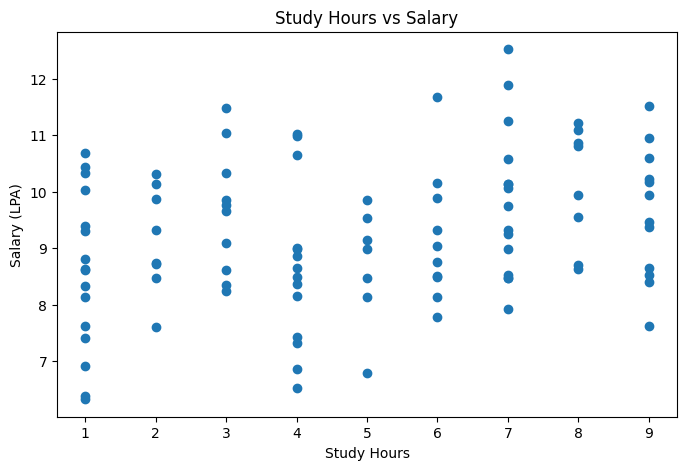

In [ ]:
plt.figure(figsize=(8,5))

plt.scatter(df["Study Hours"], df["Salary"])

plt.xlabel("Study Hours")
plt.ylabel("Salary (LPA)")
plt.title("Study Hours vs Salary")

plt.show()

Correlation matrix

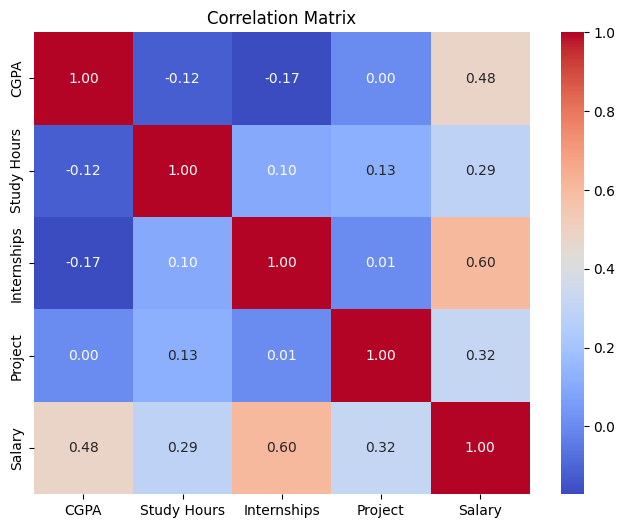

In [ ]:
plt.figure(figsize=(8,6))

correlation = df.corr()

sns.heatmap(correlation, annot=True, cmap="coolwarm", fmt=".2f")

plt.title("Correlation Matrix")

plt.show()

Define X an Y

In [ ]:
X = df[["CGPA",
        "Study Hours",
        "Internships",
        "Project"]]
y = df["Salary"]

Train-test split

In [ ]:
from sklearn.model_selection import train_test_split

X_train , X_test, y_train, y_test = train_test_split(
    X,y,
    test_size=0.2,
    random_state=42
)

print("Training data: ",X_train.shape)
print("Testing data: ",X_test.shape)

Training data:  (80, 4)
Testing data:  (20, 4)


Train Linear Regression

In [ ]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train, y_train)

LinearRegression()

Get coefficients

In [ ]:
print("Intercept:")
print(model.intercept_)

print("\nCoefficients: ")

for feature, coefficient in zip(
    X.columns,
    model.coef_
):

    print(feature, ":", coefficient)

Intercept:
1.84163928159127

Coefficients: 
CGPA : 0.6313544280396315
Study Hours : 0.13960879065843745
Internships : 0.725357769356446
Project : 0.27331990070415735


Make prediction

In [ ]:
y_pred = model.predict(X_test)

print("Actual values: ")
print(y_test.values[:10])

print("\nPredicted values: ")
print(y_pred[:10])

Actual values: 
[ 7.92 11.89 10.14  8.48  7.41  6.92 10.6   9.77  8.5   9.25]

Predicted values: 
[ 8.18585131 11.44477783 10.23339806  8.81017038  7.42649841  7.466917
  9.81546754  9.89387731  9.02587832  9.75722401]


In [ ]:
result = pd.DataFrame({
    "Actual_Salary":y_test.values,
    "Predicted_Salary":np.round(y_pred,2)
})

print(result.head(10))

   Actual_Salary  Predicted_Salary
0           7.92              8.19
1          11.89             11.44
2          10.14             10.23
3           8.48              8.81
4           7.41              7.43
5           6.92              7.47
6          10.60              9.82
7           9.77              9.89
8           8.50              9.03
9           9.25              9.76


Evaluate the model

In [ ]:
from sklearn.metrics import mean_squared_error,mean_absolute_error, r2_score

mse = mean_absolute_error(y_test, y_pred)

mse = mean_squared_error(y_test, y_pred)

rmse = np.sqrt(mse)

r2 = r2_score(y_test, y_pred)

print("Mean Squared Error: ", mse)
print("R-squared: ", r2)

Mean Squared Error:  0.31712393032086716
R-squared:  0.7577756991047565
